# Compare Erbs and DIRINDEX decomposition
This notebook explores the difference between Erbs and DIRINDEX decomposition (estimating DNI, DHI, from GHI). It uses observations from a SURFRAD ground station as the reference, with intraday forecasts from IFS and GFS for testing.

Also see https://assessingsolar.org/notebooks/decomposition_models.html. Note that the Asessing Solar example uses CAMS historical data (not the CAMS forecast) for clear sky irradiance, and pvlib documentation recommends Ineichen clearsky with `perez_enhacement=True`, but hefty currently uses Simplified Solis. 

In [1]:
import pandas as pd
import pvlib
import numpy as np
import matplotlib.pyplot as plt
import hefty
from ftplib import FTP  # for getting SURFRAD station data

Let's ignore xarray `FutureWarning`s (this should be addressed in Herbie before too long, see https://github.com/blaylockbk/Herbie/issues/525).

Also ignore warnings about not removing GRIB files.

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings(
    action='ignore',
    category=UserWarning,
    message='.*Will not remove GRIB file because it previously existed.*')

## Get SURFRAD Observations
Get SURFRAD data from Goodwin Creek, MS (`'GCR'`). Start with a list of files for 2026:

In [3]:
station_dir = 'Goodwin_Creek_MS'
year = '2026'
ftp = FTP('aftp.cmdl.noaa.gov')
ftp.login()
ftp.cwd('data/radiation/surfrad/' + station_dir + '/' + year) # change directory
filelist = ftp.nlst()

We will work with data for January 18-22:

In [4]:
files_we_want = filelist[17:22]  # 18th file is index=17...
files_we_want

['gwn26018.dat',
 'gwn26019.dat',
 'gwn26020.dat',
 'gwn26021.dat',
 'gwn26022.dat']

In [5]:
folder = 'ftp://aftp.cmdl.noaa.gov/data/radiation/surfrad'
obs = []
# loop through files we want
for file in files_we_want:
    full_filename = f'{folder}/{station_dir}/{year}/{file}'
    obs_temp, metadata = pvlib.iotools.read_surfrad(full_filename, map_variables=True)
    obs.append(obs_temp)
    print(f'downloaded {file}')

obs = pd.concat(obs)
# remove duplicate rows, if any exist
obs = obs[~obs.index.duplicated(keep='last')]

downloaded gwn26018.dat
downloaded gwn26019.dat
downloaded gwn26020.dat
downloaded gwn26021.dat
downloaded gwn26022.dat


In [6]:
metadata

{'name': 'Goodwin Creek',
 'latitude': 34.25,
 'longitude': -89.87,
 'elevation': 98.0,
 'surfrad_version': 1,
 'tz': 'UTC'}

In [7]:
obs.head()

,year,jday,month,day,hour,minute,dt,solar_zenith,ghi,ghi_flag,...,temp_air,temp_air_flag,relative_humidity,relative_humidity_flag,wind_speed,wind_speed_flag,wind_direction,wind_direction_flag,pressure,pressure_flag
2026-01-18 00:00:00+00:00,2026,18,1,18,0,0,0.000,99.40,-1.0,0,...,1.2,0,33.7,0,0.4,0,350.8,0,1013.9,0
2026-01-18 00:01:00+00:00,2026,18,1,18,0,1,0.017,99.60,-1.0,0,...,1.2,0,34.0,0,0.0,0,0.0,0,1013.9,0
2026-01-18 00:02:00+00:00,2026,18,1,18,0,2,0.033,99.79,-0.7,0,...,1.2,0,33.7,0,0.5,0,325.6,0,1013.9,0
2026-01-18 00:03:00+00:00,2026,18,1,18,0,3,0.050,99.99,-0.7,0,...,1.1,0,34.1,0,0.0,0,0.0,0,1013.9,0
2026-01-18 00:04:00+00:00,2026,18,1,18,0,4,0.067,100.18,-0.7,0,...,1.1,0,34.5,0,0.0,0,344.8,0,1013.9,0


Plot of the data:

<Axes: >

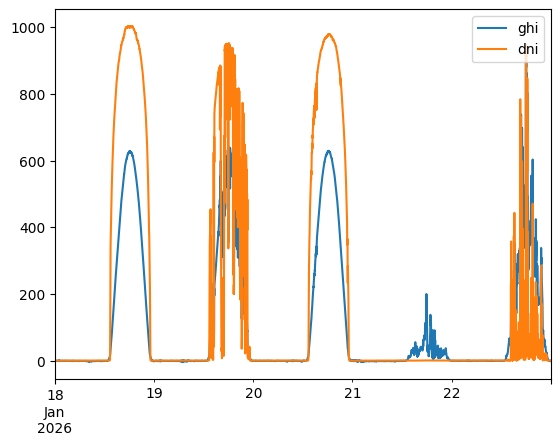

In [8]:
obs[['ghi', 'dni']].plot()

In [9]:
# list of dates
dates = obs.index.normalize().unique()
dates

DatetimeIndex(['2026-01-18 00:00:00+00:00', '2026-01-19 00:00:00+00:00',
               '2026-01-20 00:00:00+00:00', '2026-01-21 00:00:00+00:00',
               '2026-01-22 00:00:00+00:00'],
              dtype='datetime64[us, UTC]', freq=None)

Now, we will run through several days, testing IFS and GFS with both Erbs and DIRINDEX. We will skip the 4th day because it is heavily overcast with essentially zero DNI. 

We will only look at GHI and DNI, ignoring DHI. We will calculate mean absolute error (MAE) for hourly DNI. 

## IFS, day 1

In [10]:
model = 'ifs'
priority = 'azure'
day_num = 1

# first day, 11 AM UTC (~5 AM local time)
available_date = dates[day_num-1]+pd.Timedelta(hours=11)

init_date, run_length, lead_time_to_start = hefty.utilities.adjust_forecast_datetimes(
    available_date=available_date,
    run_length_needed=18,
    lead_time_to_start_needed=0,
    model=model
)

resource_erbs = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='erbs'
)

In [12]:
resource_dirindex = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='dirindex'
)

### Results

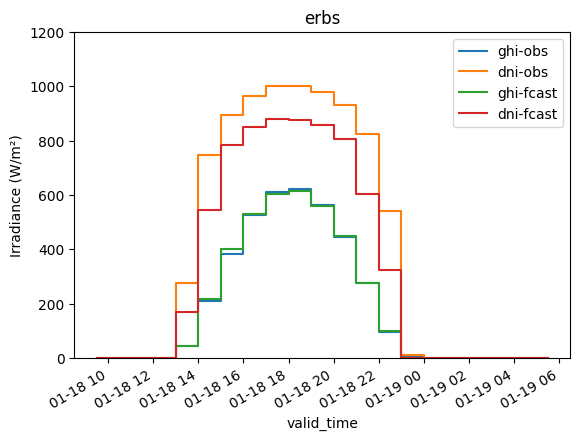

Erbs DNI MAE: 70.16680022325805 W/m²


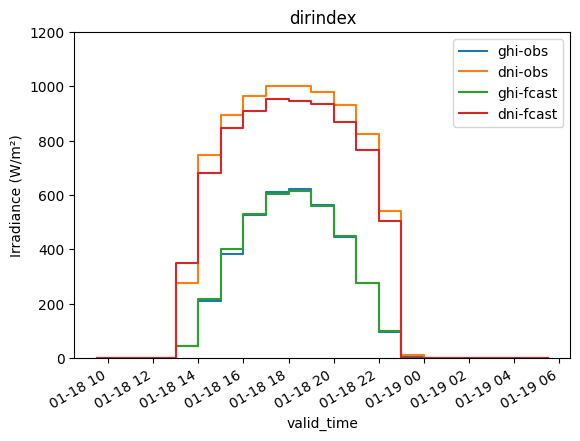

DIRINDEX DNI MAE: 26.71461451973783 W/m²


In [13]:
fcast = resource_erbs.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('erbs')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'Erbs DNI MAE: {mae} W/m²')

fcast = resource_dirindex.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('dirindex')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'DIRINDEX DNI MAE: {mae} W/m²')

## GFS, day 1

In [14]:
model = 'gfs'
priority = 'aws'
day_num = 1

# first day, 11 AM UTC (~5 AM local time)
available_date = dates[day_num-1]+pd.Timedelta(hours=11)

init_date, run_length, lead_time_to_start = hefty.utilities.adjust_forecast_datetimes(
    available_date=available_date,
    run_length_needed=18,
    lead_time_to_start_needed=0,
    model=model
)

resource_erbs = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='erbs'
)

In [15]:
resource_dirindex = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='dirindex'
)

### Results

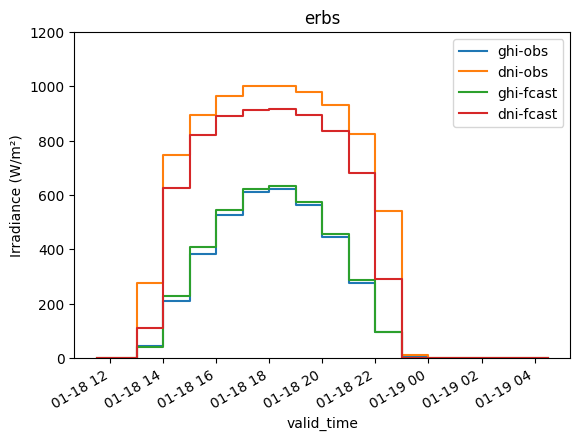

Erbs DNI MAE: 66.17406014206134 W/m²


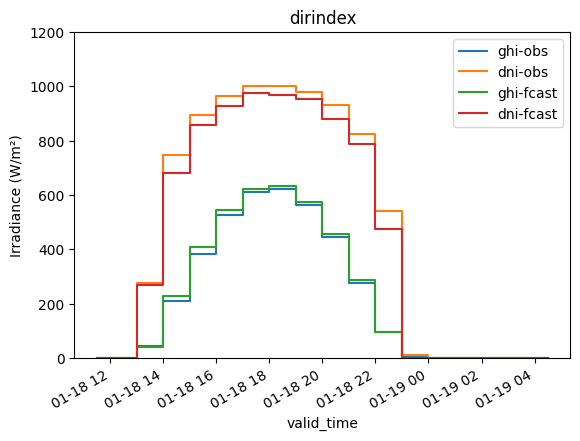

DIRINDEX DNI MAE: 21.840367430375046 W/m²


In [16]:
fcast = resource_erbs.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('erbs')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'Erbs DNI MAE: {mae} W/m²')

fcast = resource_dirindex.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('dirindex')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'DIRINDEX DNI MAE: {mae} W/m²')

## IFS, day 2

In [17]:
model = 'ifs'
priority = 'azure'
day_num = 2

# first day, 11 AM UTC (~5 AM local time)
available_date = dates[day_num-1]+pd.Timedelta(hours=11)

init_date, run_length, lead_time_to_start = hefty.utilities.adjust_forecast_datetimes(
    available_date=available_date,
    run_length_needed=18,
    lead_time_to_start_needed=0,
    model=model
)

resource_erbs = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='erbs'
)

In [18]:
resource_dirindex = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='dirindex'
)

### Results

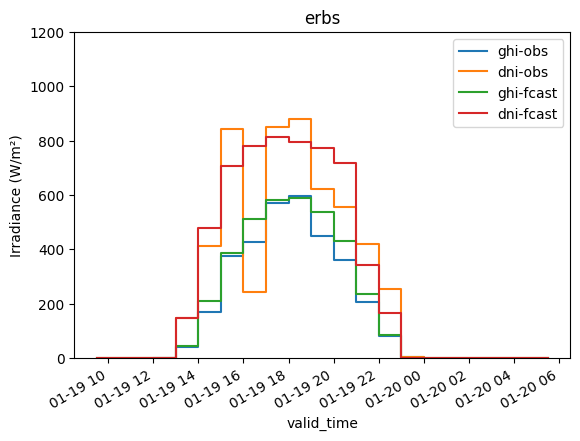

Erbs DNI MAE: 64.13316308287364 W/m²


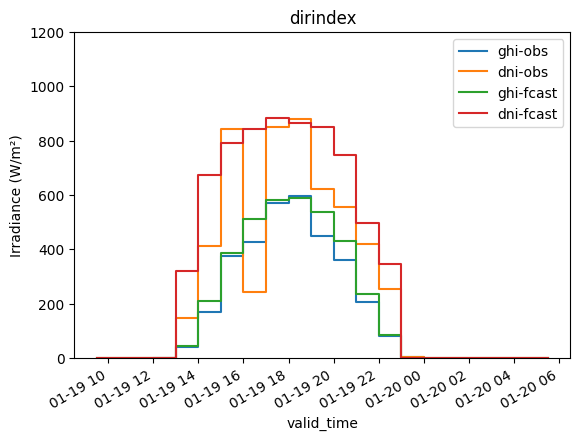

DIRINDEX DNI MAE: 82.23714050640481 W/m²


In [19]:
fcast = resource_erbs.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('erbs')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'Erbs DNI MAE: {mae} W/m²')

fcast = resource_dirindex.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('dirindex')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'DIRINDEX DNI MAE: {mae} W/m²')

## GFS, day 2

In [20]:
model = 'gfs'
priority = 'aws'
day_num = 2

# first day, 11 AM UTC (~5 AM local time)
available_date = dates[day_num-1]+pd.Timedelta(hours=11)

init_date, run_length, lead_time_to_start = hefty.utilities.adjust_forecast_datetimes(
    available_date=available_date,
    run_length_needed=18,
    lead_time_to_start_needed=0,
    model=model
)

resource_erbs = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='erbs'
)

In [21]:
resource_dirindex = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='dirindex'
)

### Results

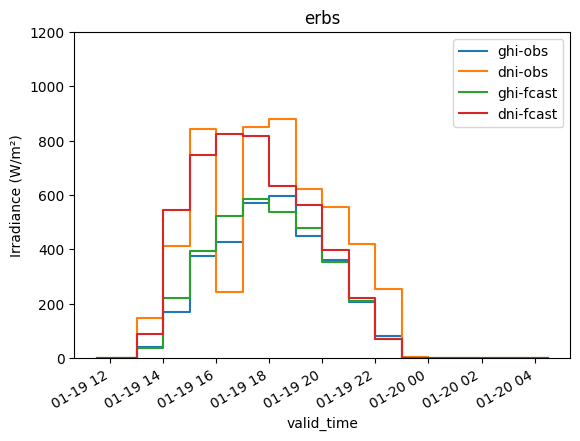

Erbs DNI MAE: 97.28922273996898 W/m²


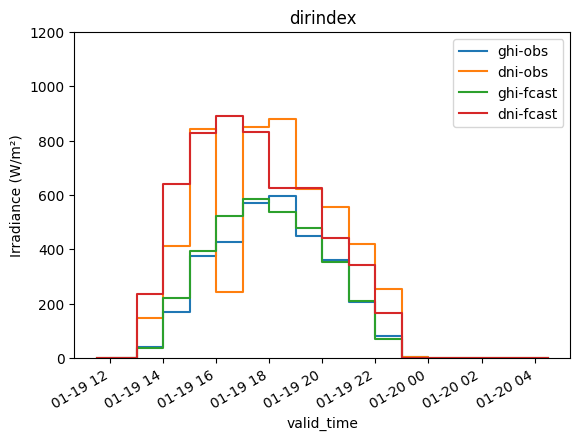

DIRINDEX DNI MAE: 85.41224943951502 W/m²


In [22]:
fcast = resource_erbs.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('erbs')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'Erbs DNI MAE: {mae} W/m²')

fcast = resource_dirindex.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('dirindex')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'DIRINDEX DNI MAE: {mae} W/m²')

## IFS, day 3

In [23]:
model = 'ifs'
priority = 'azure'
day_num = 3

# first day, 11 AM UTC (~5 AM local time)
available_date = dates[day_num-1]+pd.Timedelta(hours=11)

init_date, run_length, lead_time_to_start = hefty.utilities.adjust_forecast_datetimes(
    available_date=available_date,
    run_length_needed=18,
    lead_time_to_start_needed=0,
    model=model
)

resource_erbs = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='erbs'
)

In [24]:
resource_dirindex = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='dirindex'
)

### Results

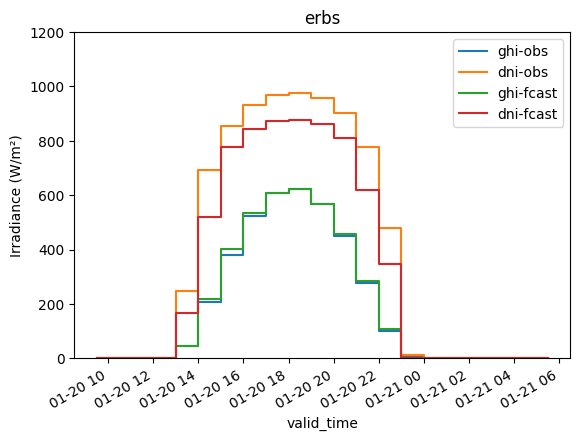

Erbs DNI MAE: 52.80358064547218 W/m²


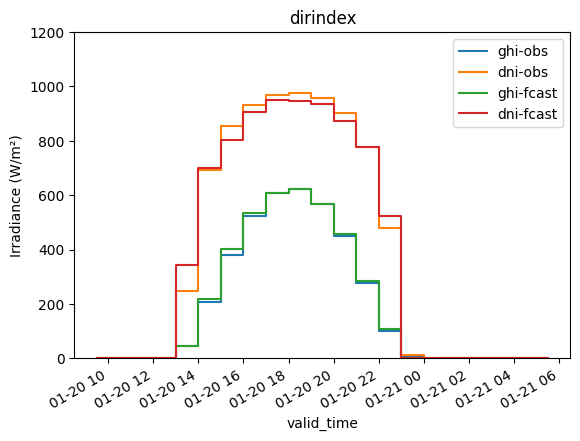

DIRINDEX DNI MAE: 16.01393367653016 W/m²


In [25]:
fcast = resource_erbs.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('erbs')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'Erbs DNI MAE: {mae} W/m²')

fcast = resource_dirindex.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('dirindex')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'DIRINDEX DNI MAE: {mae} W/m²')

## GFS, day 3

In [26]:
model = 'gfs'
priority = 'aws'
day_num = 3

# first day, 11 AM UTC (~5 AM local time)
available_date = dates[day_num-1]+pd.Timedelta(hours=11)

init_date, run_length, lead_time_to_start = hefty.utilities.adjust_forecast_datetimes(
    available_date=available_date,
    run_length_needed=18,
    lead_time_to_start_needed=0,
    model=model
)

resource_erbs = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='erbs'
)

In [27]:
resource_dirindex = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='dirindex'
)

### Results

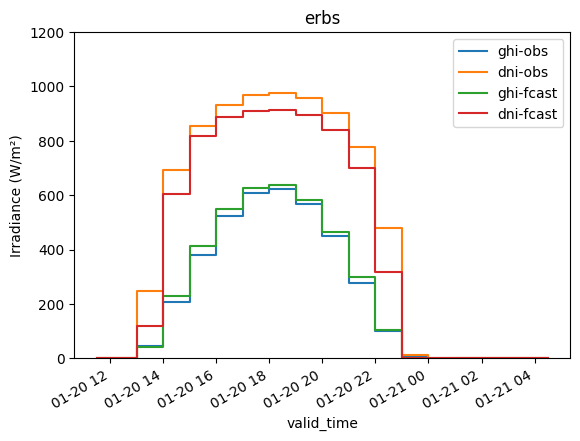

Erbs DNI MAE: 44.404314959216 W/m²


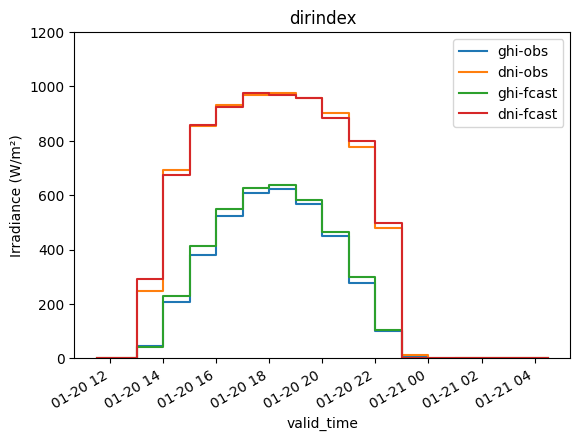

DIRINDEX DNI MAE: 9.129286369556755 W/m²


In [28]:
fcast = resource_erbs.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('erbs')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'Erbs DNI MAE: {mae} W/m²')

fcast = resource_dirindex.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('dirindex')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'DIRINDEX DNI MAE: {mae} W/m²')

## IFS, day 5

In [29]:
model = 'ifs'
priority = 'azure'
day_num = 5

# first day, 11 AM UTC (~5 AM local time)
available_date = dates[day_num-1]+pd.Timedelta(hours=11)

init_date, run_length, lead_time_to_start = hefty.utilities.adjust_forecast_datetimes(
    available_date=available_date,
    run_length_needed=18,
    lead_time_to_start_needed=0,
    model=model
)

resource_erbs = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='erbs'
)

In [30]:
resource_dirindex = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='dirindex'
)

### Results

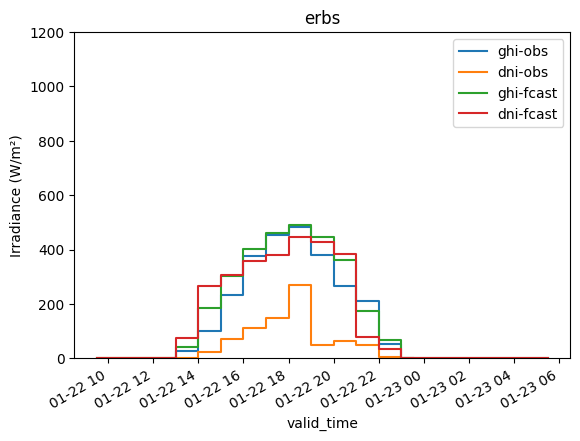

Erbs DNI MAE: 130.61786283579565 W/m²


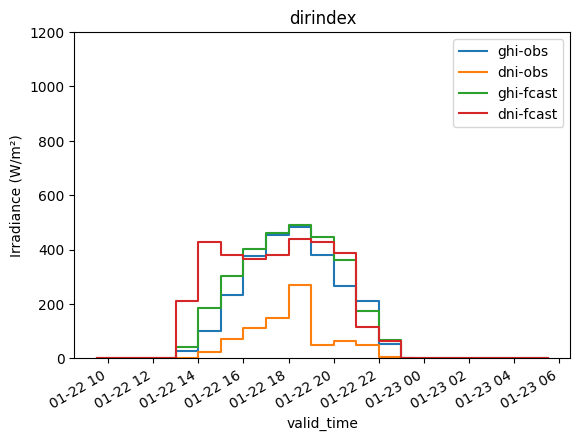

DIRINDEX DNI MAE: 160.00045246078741 W/m²


In [31]:
fcast = resource_erbs.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('erbs')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'Erbs DNI MAE: {mae} W/m²')

fcast = resource_dirindex.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('dirindex')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'DIRINDEX DNI MAE: {mae} W/m²')

## GFS, day 5

In [32]:
model = 'gfs'
priority = 'aws'
day_num = 5

# first day, 11 AM UTC (~5 AM local time)
available_date = dates[day_num-1]+pd.Timedelta(hours=11)

init_date, run_length, lead_time_to_start = hefty.utilities.adjust_forecast_datetimes(
    available_date=available_date,
    run_length_needed=18,
    lead_time_to_start_needed=0,
    model=model
)

resource_erbs = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='erbs'
)

In [33]:
resource_dirindex = hefty.solar.get_solar_forecast_fast(
    latitude=metadata['latitude'],
    longitude=metadata['longitude'],
    init_date=init_date,
    run_length=run_length,
    lead_time_to_start=lead_time_to_start,
    model=model,
    priority=priority,
    decomp_model='dirindex'
)

### Results

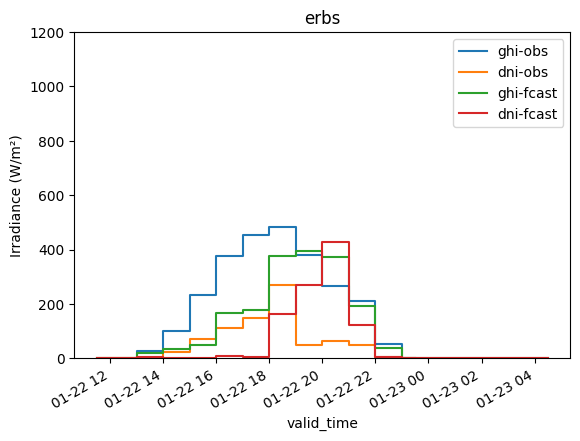

Erbs DNI MAE: 85.67589927575158 W/m²


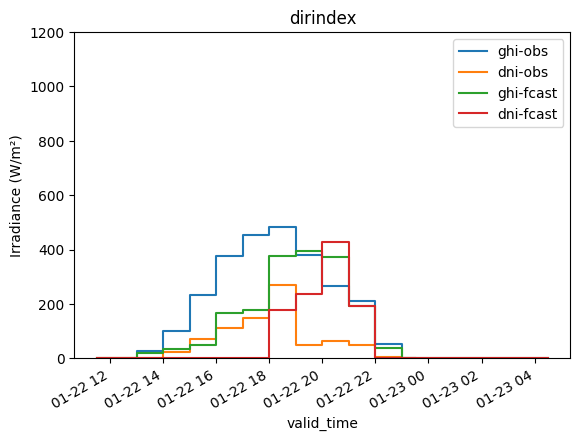

DIRINDEX DNI MAE: 88.4397528509457 W/m²


In [34]:
fcast = resource_erbs.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('erbs')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'Erbs DNI MAE: {mae} W/m²')

fcast = resource_dirindex.copy()

# calculate hourly avg obs, plot obs and fcast
obs_1h = obs[(obs.index >= fcast.index.min()) & (obs.index <= fcast.index.max())][['ghi', 'dni', 'dhi']].resample('1h').mean()
obs_1h.index = obs_1h.index + pd.Timedelta('30min')
obs_1h['ghi'].plot(drawstyle='steps-mid', label='ghi-obs')
obs_1h['dni'].plot(drawstyle='steps-mid', label='dni-obs')
fcast['ghi'].plot(drawstyle='steps-mid', label='ghi-fcast')
fcast['dni'].plot(drawstyle='steps-mid', label='dni-fcast')
plt.legend()
plt.ylim([0,1200])
plt.ylabel('Irradiance (W/m²)')
plt.title('dirindex')
plt.show()

# DNI error
mae = np.mean(np.abs(obs_1h['dni'] - fcast['dni']))
print(f'DIRINDEX DNI MAE: {mae} W/m²')

## Conclusion

DIRINDEX seems to do better than Erbs in general, particularly on clear days and with GFS. 

_This document/data/output/Results is/are based on data and products of the European Centre for Medium-Range Weather Forecasts (ECMWF). © 2026 European Centre for Medium-Range Weather Forecasts (ECMWF), www.ecmwf.int. This data is published under a Creative Commons Attribution 4.0 International (CC BY 4.0). https://creativecommons.org/licenses/by/4.0/. ECMWF does not accept any liability whatsoever for any error or omission in the data, their availability, or for any loss or damage arising from their use._

_ECMWF Data have been modified using the functions included in the hefty Python package (e.g., interpolation to hourly values)._